# **Importing the Required Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV,GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_curve, roc_auc_score


# **Loading and Preprocessing of Data**

In [2]:
df = pd.read_csv("/content/Instagram_fake_profile_dataset.csv")
print(df.head(5))
print(df.tail(5))

   profile pic  nums/length username  fullname words  nums/length fullname  \
0            1                  0.27               0                   0.0   
1            1                  0.00               2                   0.0   
2            1                  0.10               2                   0.0   
3            1                  0.00               1                   0.0   
4            1                  0.00               2                   0.0   

   name==username  description length  external URL  private  #posts  \
0               0                  53             0        0      32   
1               0                  44             0        0     286   
2               0                   0             0        1      13   
3               0                  82             0        0     679   
4               0                   0             0        1       6   

   #followers  #follows  fake  
0        1000       955     0  
1        2740       533     0  
2 

In [3]:
#checking the shape and info of the dataset
print(df.shape)
print(df.info())

(5000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           5000 non-null   int64  
 1   nums/length username  5000 non-null   float64
 2   fullname words        5000 non-null   int64  
 3   nums/length fullname  5000 non-null   float64
 4   name==username        5000 non-null   int64  
 5   description length    5000 non-null   int64  
 6   external URL          5000 non-null   int64  
 7   private               5000 non-null   int64  
 8   #posts                5000 non-null   int64  
 9   #followers            5000 non-null   int64  
 10  #follows              5000 non-null   int64  
 11  fake                  5000 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 468.9 KB
None


In [4]:
# #checking the null values
print(df.isnull().sum())

# Check duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)
df.drop_duplicates(inplace=True)
print("Number of duplicate rows after dropping:", df.duplicated().sum())



profile pic             0
nums/length username    0
fullname words          0
nums/length fullname    0
name==username          0
description length      0
external URL            0
private                 0
#posts                  0
#followers              0
#follows                0
fake                    0
dtype: int64
Number of duplicate rows: 66
Number of duplicate rows after dropping: 0


In [5]:
print("Class Distribution:\n", df["fake"].value_counts())

Class Distribution:
 fake
0    2476
1    2458
Name: count, dtype: int64


# **Data Visualization**

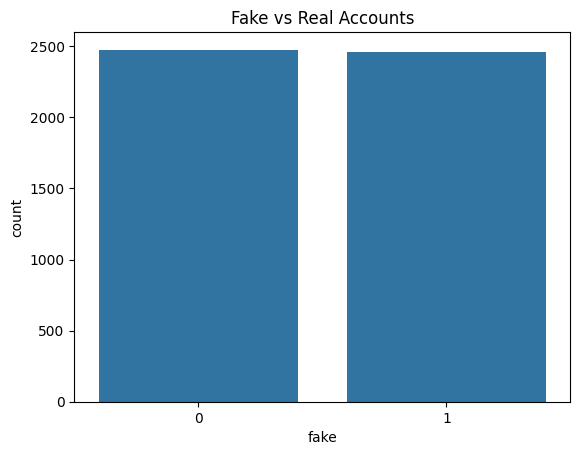

In [6]:
sns.countplot(x='fake', data=df)
plt.title("Fake vs Real Accounts")
plt.show()

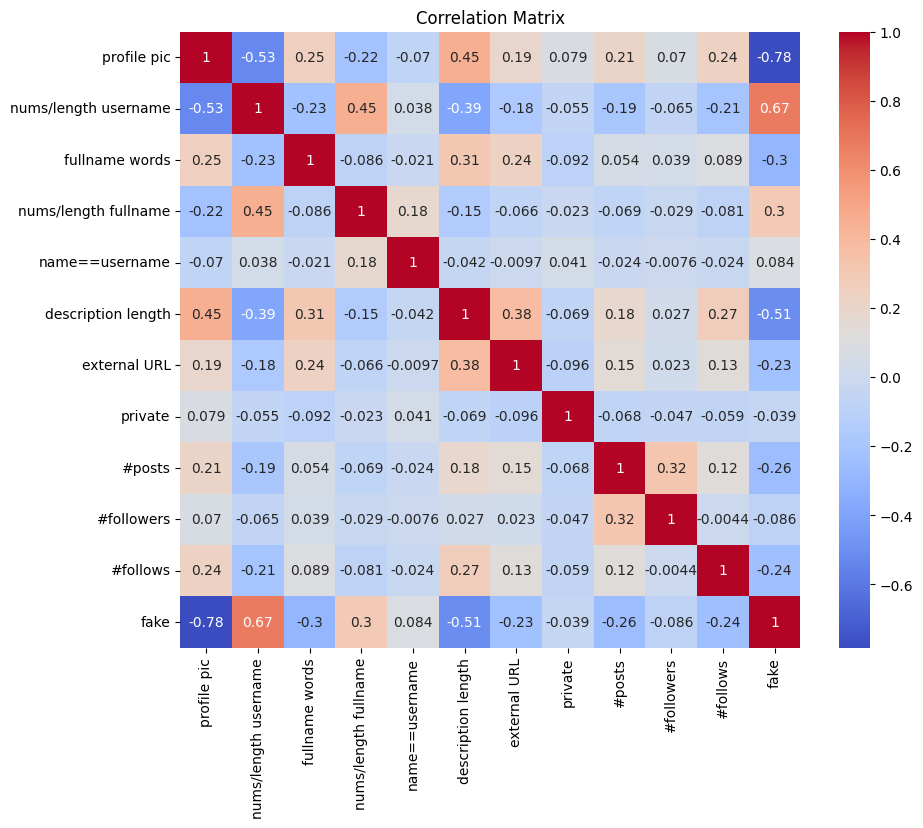

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [8]:
# FEATURES & TARGET
x = df.drop(["fake", "profile pic"], axis=1)
y = df["fake"]

In [9]:
#  TRAIN-TEST SPLIT
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
#SCALING
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


# **Logistic Regression**

In [11]:
param_lr = {
    'C': [0.01, 0.05, 0.1, 0.5, 1],
    'solver': ['lbfgs', 'liblinear'],
}

gs_lr = GridSearchCV(
    LogisticRegression(),
    param_lr,
    cv=5,
    scoring='f1'
)

gs_lr.fit(x_train_scaled, y_train)
print("Best LR Params:", gs_lr.best_params_)

best_lr = gs_lr.best_estimator_




Best LR Params: {'C': 1, 'solver': 'lbfgs'}


In [12]:
# Evaluation
train_pred = best_lr.predict(x_train_scaled)
test_pred = best_lr.predict(x_test_scaled)

print("\nLogistic Regression")
print(f"Train Accuracy : {accuracy_score(y_train, train_pred):.4f}")
print(f"Test Accuracy  : {accuracy_score(y_test, test_pred):.4f}")

print("Precision:", precision_score(y_test, test_pred))
print("Recall   :", recall_score(y_test, test_pred))
print("F1 Score :", f1_score(y_test, test_pred))
lr_pred = best_lr.predict(x_test_scaled)

print("\n Classification Report for  Logistic Regression:")
print(classification_report(y_test, lr_pred, target_names=['Real', 'Fake']))


Logistic Regression
Train Accuracy : 0.9090
Test Accuracy  : 0.9139
Precision: 0.9127789046653144
Recall   : 0.9146341463414634
F1 Score : 0.9137055837563451

 Classification Report for  Logistic Regression:
              precision    recall  f1-score   support

        Real       0.91      0.91      0.91       495
        Fake       0.91      0.91      0.91       492

    accuracy                           0.91       987
   macro avg       0.91      0.91      0.91       987
weighted avg       0.91      0.91      0.91       987



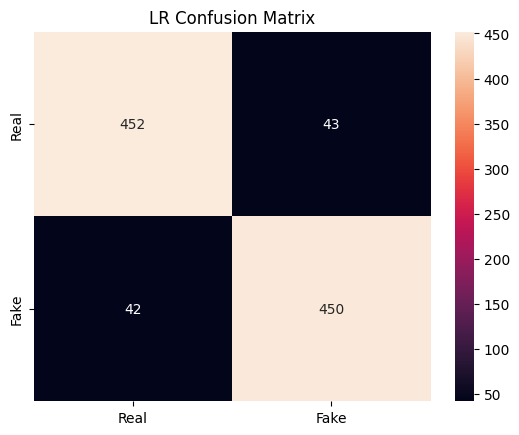

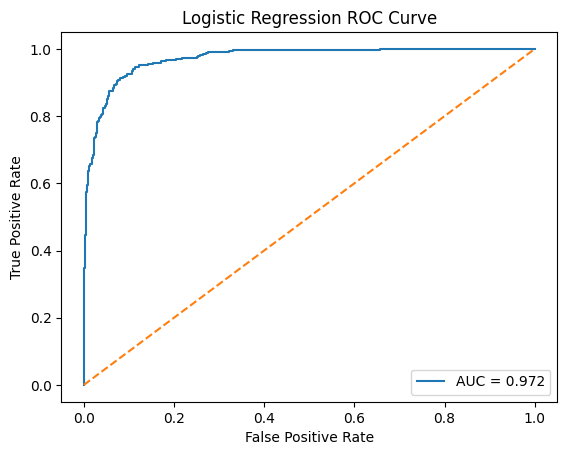

In [13]:
#Displaying Confusion Matrix
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title("LR Confusion Matrix")
plt.show()


# Probabilities
lr_probs = best_lr.predict_proba(x_test_scaled)[:, 1]

# ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc = roc_auc_score(y_test, lr_probs)

# Plot
plt.figure()
plt.plot(lr_fpr, lr_tpr, label=f"AUC = {lr_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

# **SVM**

In [14]:
param_svm = {
    'C': [0.1, 0.5, 1],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.01, 0.1],
}

gs_svm = GridSearchCV(
    SVC(probability=True),
    param_svm,
    cv=5,
    scoring='f1'
)

gs_svm.fit(x_train_scaled, y_train)
print("Best SVM Params:", gs_svm.best_params_)

best_svm = gs_svm.best_estimator_




Best SVM Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [15]:
# Evaluation
train_pred = best_svm.predict(x_train_scaled)
test_pred = best_svm.predict(x_test_scaled)

print("\nSVM")
print(f"Train Accuracy : {accuracy_score(y_train, train_pred):.3f}")
print(f"Test Accuracy  : {accuracy_score(y_test, test_pred):.3f}")

print("Precision:", precision_score(y_test, test_pred))
print("Recall   :", recall_score(y_test, test_pred))
print("F1 Score :", f1_score(y_test, test_pred))
svm_pred = best_svm.predict(x_test_scaled)

print("\n Classification Report of SVM:")
print(classification_report(y_test, svm_pred, target_names=['Real', 'Fake']))


SVM
Train Accuracy : 0.927
Test Accuracy  : 0.921
Precision: 0.9156626506024096
Recall   : 0.926829268292683
F1 Score : 0.9212121212121213

 Classification Report of SVM:
              precision    recall  f1-score   support

        Real       0.93      0.92      0.92       495
        Fake       0.92      0.93      0.92       492

    accuracy                           0.92       987
   macro avg       0.92      0.92      0.92       987
weighted avg       0.92      0.92      0.92       987



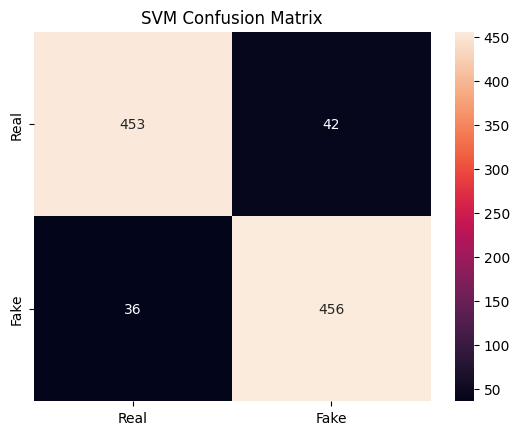

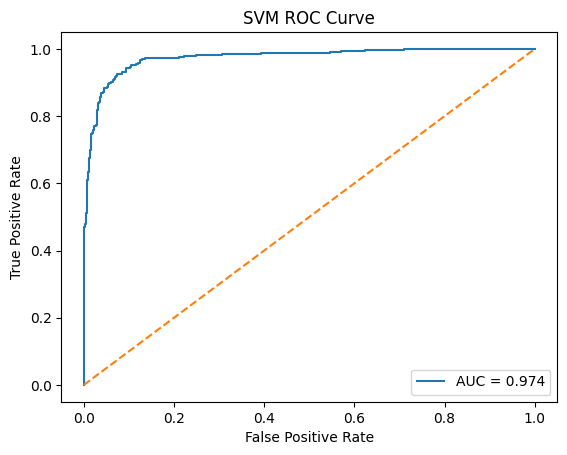

In [16]:
#Displaying Confusion Matrix
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title("SVM Confusion Matrix")
plt.show()

svm_probs = best_svm.predict_proba(x_test_scaled)[:, 1]

# ROC
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)
svm_auc = roc_auc_score(y_test, svm_probs)

# Plot
plt.figure()
plt.plot(svm_fpr, svm_tpr, label=f"AUC = {svm_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()

# **Decision Tree**


In [17]:
param_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [4,5,6],
    'min_samples_split': [12, 13, 15],
    'min_samples_leaf': [6, 7, 8]
}

rs_dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    n_iter=5,
    cv=5,
    random_state=42,
    scoring='f1'
)

rs_dt.fit(x_train, y_train)
print("Best DT Params:", rs_dt.best_params_)

best_dt = rs_dt.best_estimator_





Best DT Params: {'min_samples_split': 13, 'min_samples_leaf': 7, 'max_depth': 6, 'criterion': 'entropy'}


In [18]:
# Evaluation
train_pred = best_dt.predict(x_train)
test_pred = best_dt.predict(x_test)

print("\nDecision Tree")
print(f"Train Accuracy : {accuracy_score(y_train, train_pred):.4f}")
print(f"Test Accuracy  : {accuracy_score(y_test, test_pred):.4f}")

print("Precision is :", precision_score(y_test, test_pred))
print("Recall is   :", recall_score(y_test, test_pred))
print("F1 Score is  :", f1_score(y_test, test_pred))
dt_pred = best_dt.predict(x_test)

print("\n Classification Report for Decision Tree:")
print(classification_report(y_test, dt_pred, target_names=['Real', 'Fake']))


Decision Tree
Train Accuracy : 0.9605
Test Accuracy  : 0.9493
Precision is : 0.9510204081632653
Recall is   : 0.9471544715447154
F1 Score is  : 0.9490835030549898

 Classification Report for Decision Tree:
              precision    recall  f1-score   support

        Real       0.95      0.95      0.95       495
        Fake       0.95      0.95      0.95       492

    accuracy                           0.95       987
   macro avg       0.95      0.95      0.95       987
weighted avg       0.95      0.95      0.95       987



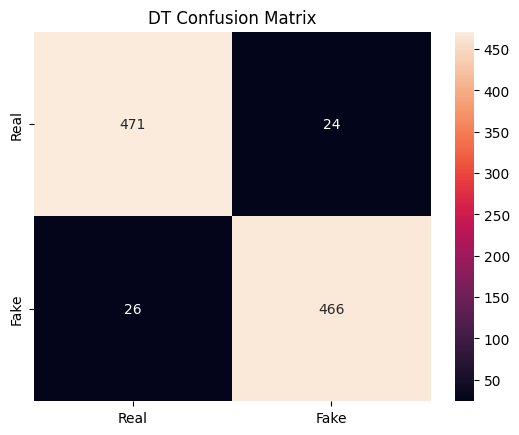

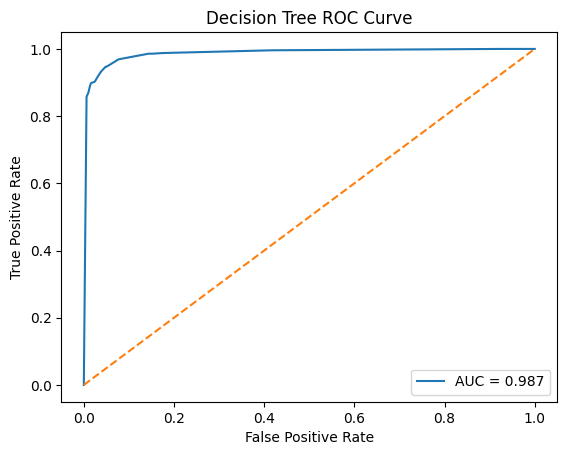

In [19]:
#Displaying of  Confusion Matrix
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title("DT Confusion Matrix")
plt.show()

# Probabilities
dt_probs = best_dt.predict_proba(x_test)[:, 1]

# ROC
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
dt_auc = roc_auc_score(y_test, dt_probs)

# Plot
plt.figure()
plt.plot(dt_fpr, dt_tpr, label=f"AUC = {dt_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.show()

# **Random Forest**

In [20]:
param_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [4, 6, 8],
    'min_samples_split': [15, 20, 25],
    'min_samples_leaf': [5, 7, 10],
    'max_features': ['sqrt', 'log2'],
    'max_samples': [0.6, 0.7],
}

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    n_iter=10,
    cv=5,
    random_state=42,
    scoring='f1'
)

rs_rf.fit(x_train, y_train)
print("Best RF Params:", rs_rf.best_params_)

best_rf = rs_rf.best_estimator_




Best RF Params: {'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_samples': 0.6, 'max_features': 'sqrt', 'max_depth': 8}


In [21]:
# Evaluation
train_pred = best_rf.predict(x_train)
test_pred = best_rf.predict(x_test)

print("\nRandom Forest")
print(f"Train Accuracy : {accuracy_score(y_train, train_pred):.4f}")
print(f"Test Accuracy  : {accuracy_score(y_test, test_pred):.4f}")

print("Precision:", precision_score(y_test, test_pred))
print("Recall   :", recall_score(y_test, test_pred))
print("F1 Score :", f1_score(y_test, test_pred))
rf_pred = best_rf.predict(x_test)

print("\n Classification Report (Random Forest):")
print(classification_report(y_test, rf_pred, target_names=['Real', 'Fake']))


Random Forest
Train Accuracy : 0.9706
Test Accuracy  : 0.9615
Precision: 0.9651639344262295
Recall   : 0.9573170731707317
F1 Score : 0.9612244897959183

 Classification Report (Random Forest):
              precision    recall  f1-score   support

        Real       0.96      0.97      0.96       495
        Fake       0.97      0.96      0.96       492

    accuracy                           0.96       987
   macro avg       0.96      0.96      0.96       987
weighted avg       0.96      0.96      0.96       987



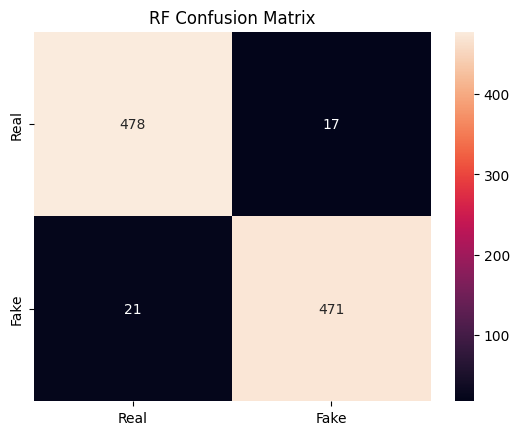

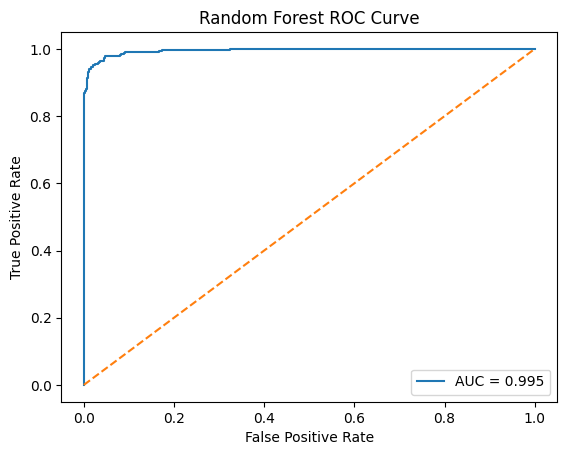

In [22]:
#Displaying Confusion Matrix
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title("RF Confusion Matrix")
plt.show()


# Probabilities
rf_probs = best_rf.predict_proba(x_test)[:, 1]

# ROC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

# Plot
plt.figure()
plt.plot(rf_fpr, rf_tpr, label=f"AUC = {rf_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

In [23]:
import pickle
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)
